# Compound Lens — Direct Fit

## Learning to Autolens / Examples / compound_lens

---

**Problem.** A single source at **z = 1.7** is deflected by **two foreground galaxies**, the first at z = 0.5 and the second at z = 0.8. This is a *compound* lens: the ray from the source passes through the z = 0.8 deflector, then the z = 0.5 deflector, then the observer. `al.Tracer` handles the recursive plane-to-plane ray-tracing automatically once you hand it galaxies at three different redshifts.

**Method.** A single free-fit with `af.Nautilus` + curated, truth-seeded priors. This is the *direct* approach — we build a 2-lens + 1-source model all at once and let Nautilus find the joint posterior. Compare against `02_compound_slam.ipynb` for the staged-chain alternative.

**Prerequisites.**
- Mod 03 (single free fit with Nautilus)
- Mod 04 (SLaM + prior-seeding intuition)
- Mod 11 (what a physical mass model looks like; this notebook ends with a Mod-11-style skill audit)

**Key references.**
- Multi-plane ray-tracing theory: Schneider, Ehlers & Falco 1992 Ch. 9; Keeton (2003) arXiv:astro-ph/0102340.
- `autolens_workspace_latest/scripts/guides/advanced/multi_plane.py` — the canonical `al.Tracer` multi-plane API.
- `autolens_workspace_latest/scripts/imaging/features/extra_galaxies/modeling.py` — fixed-centre multi-galaxy modelling.

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(
        f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set. "
        "Unset it and restart the kernel: unset PYAUTOFIT_TEST_MODE"
    )

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, IFrame, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline
print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2026.4.13.6


In [2]:
# ============================================================
# HELPER: show_result() — load the committed Cannon artifact
# ============================================================
# Mirrors the Mod 04/05 pattern. Reads summary.json + fit_subplot.png
# + corner.pdf + model_results.txt from results/<stage>/.
# ============================================================
RESULTS_ROOT = Path("results")

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for stage {stage_name!r} yet — run on Cannon or set LTA_RUN_HEAVY=1)")
        return

    summary_path = stage_dir / "summary.json"
    if summary_path.exists():
        summary = json.loads(summary_path.read_text())
        display(Markdown(
            f"### `{stage_name}`\n"
            f"- max log-likelihood: **{summary.get('max_log_likelihood'):.2f}**\n"
            f"- log evidence: **{summary.get('log_evidence'):.2f}**\n"
            f"- χ²/N = **{summary.get('chi_squared_per_pixel'):.3f}** "
            f"({summary.get('chi_squared_total'):.0f} / {summary.get('n_unmasked_pixels')} unmasked px)\n"
            f"- max |normalized residual| = **{summary.get('max_abs_normalized_residual'):.2f} σ**"
        ))

    fit_png = stage_dir / "fit_subplot.png"
    if fit_png.exists():
        display(Markdown("**Fit subplot:**"))
        display(Image(filename=str(fit_png)))

    corner_pdf = stage_dir / "corner.pdf"
    if corner_pdf.exists():
        display(Markdown("**Corner plot:**"))
        display(IFrame(src=str(corner_pdf), width=720, height=720))

    mr = stage_dir / "model_results.txt"
    if mr.exists():
        preview = "\n".join(mr.read_text().splitlines()[:40])
        display(Markdown(f"**`model_results.txt`** (first 40 lines):\n\n```\n{preview}\n```"))

---

## 1. Load the data

The mocks are simulated with `pixel_scales=0.05"` (HST-like sampling). The noise map is the image times 3% plus a small Gaussian floor — whatever the exact recipe, the `al.Imaging.from_fits` loader just consumes the three FITS files and we don't need to know more.

2026-04-24 14:15:40,351 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 9176 image-pixels


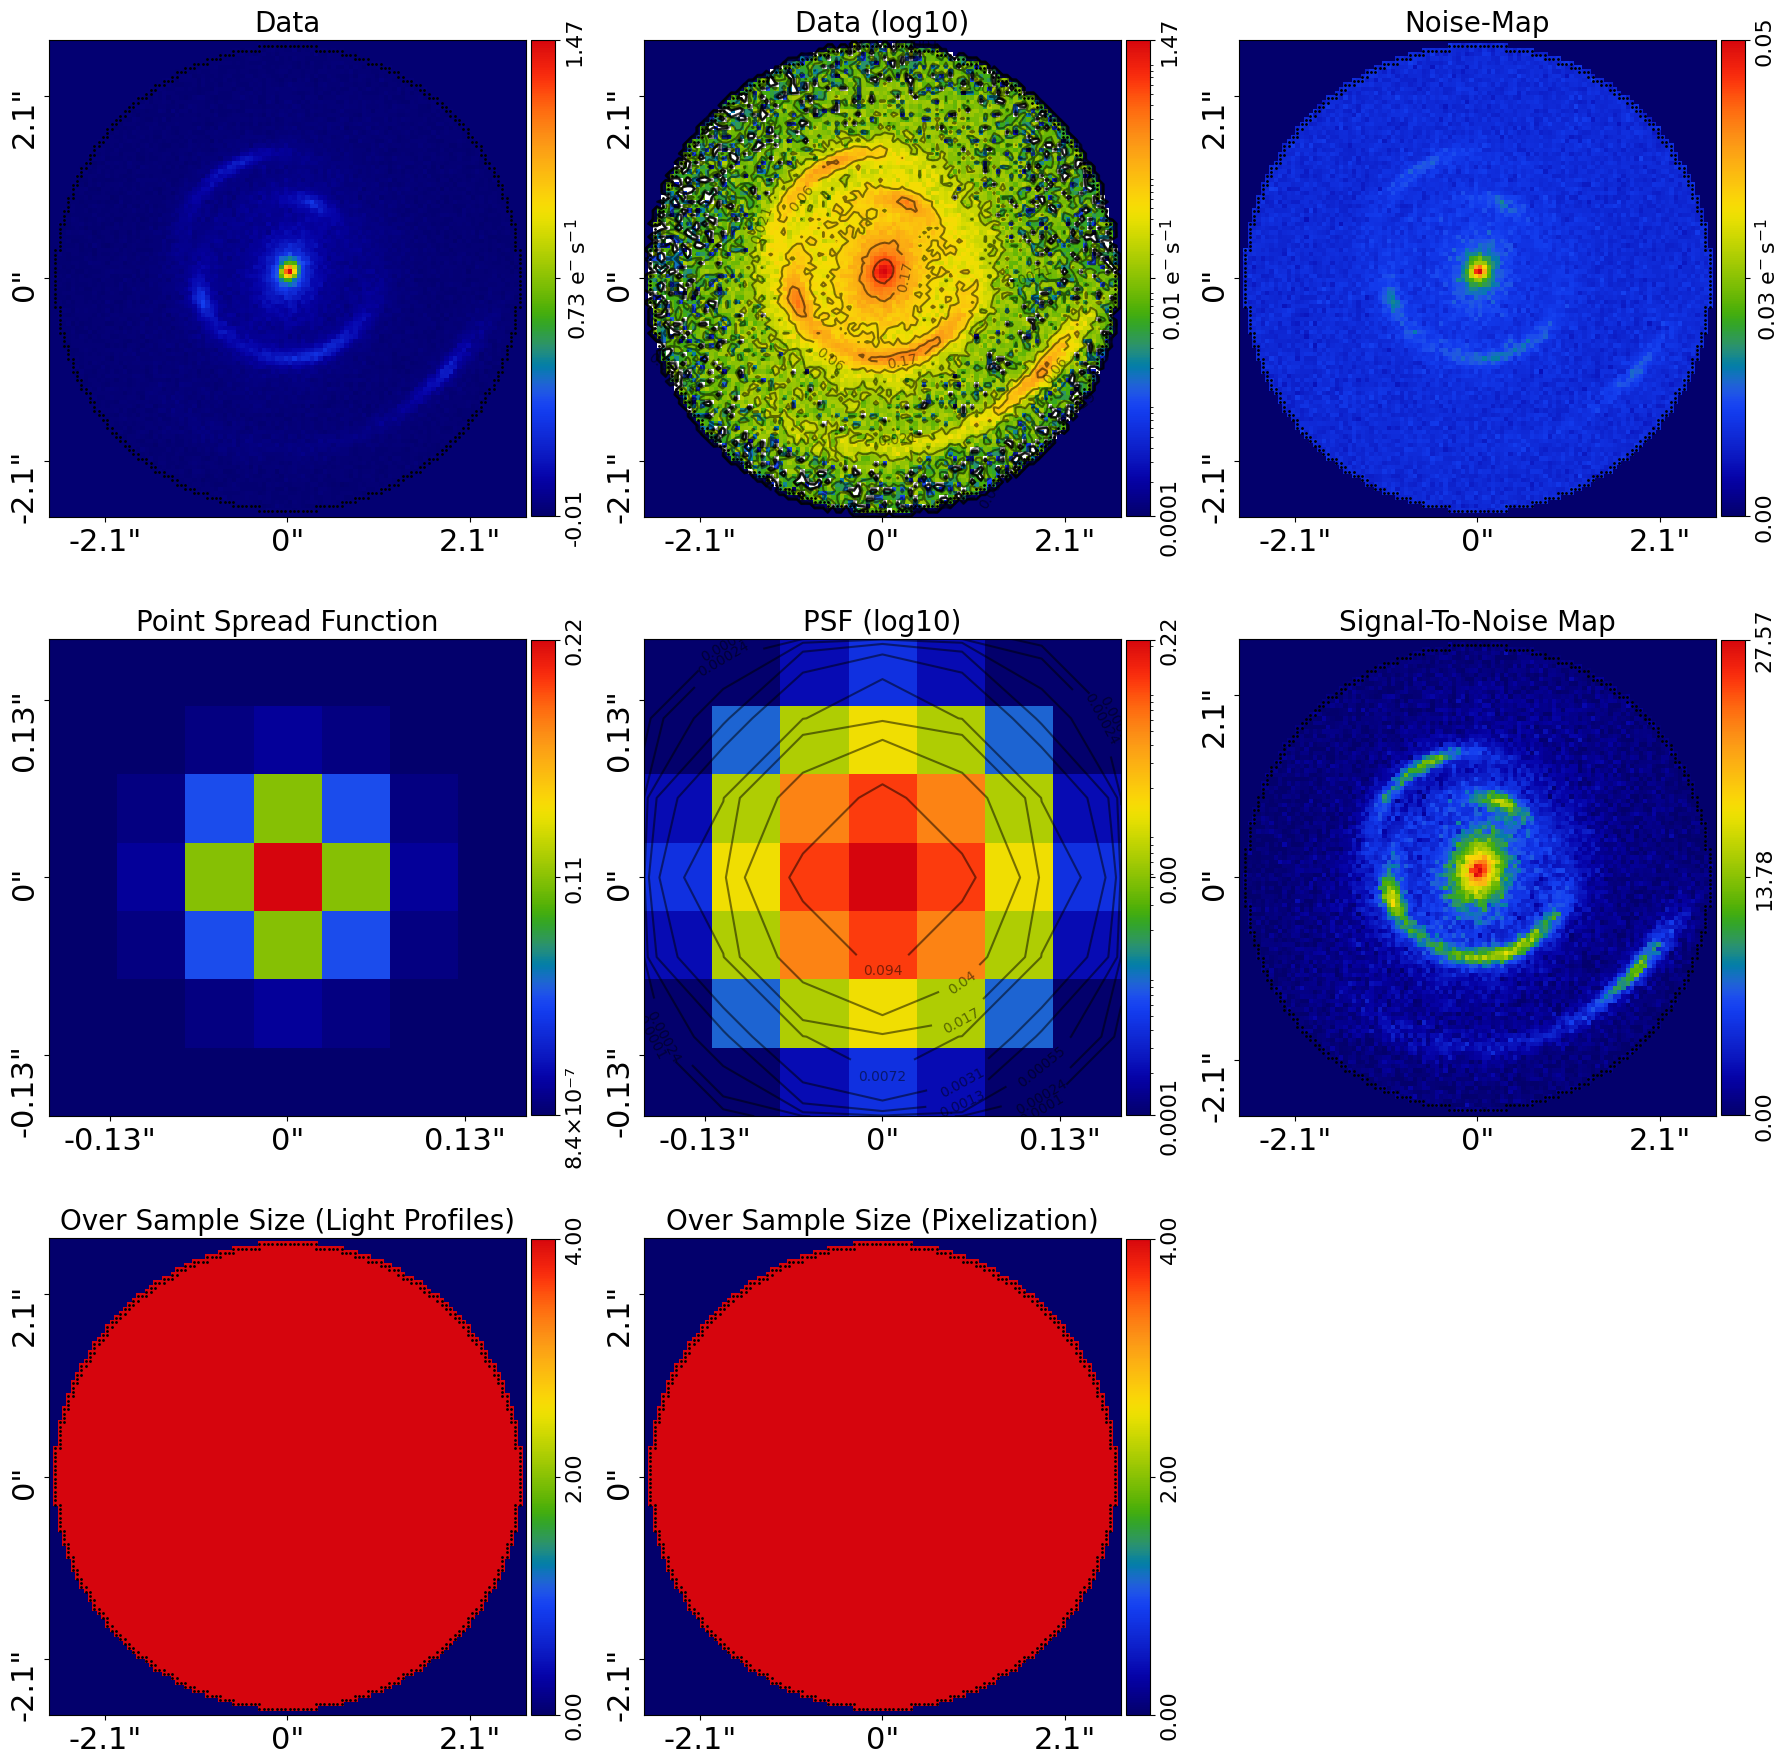

In [3]:
dataset_name = "mock_1"
dataset_path = Path("mocks")

dataset = al.Imaging.from_fits(
    data_path     = dataset_path / "mock_1_image.fits",
    noise_map_path= dataset_path / "mock_1_noise.fits",
    psf_path      = dataset_path / "mock_psf.fits",
    pixel_scales  = 0.05,
)

mask_radius = 2.7  # arcsec
mask = al.Mask2D.circular(
    shape_native = dataset.shape_native,
    pixel_scales = dataset.pixel_scales,
    radius       = mask_radius,
)
dataset = dataset.apply_mask(mask=mask)

aplt.subplot_imaging_dataset(dataset=dataset)

## 2. Image positions (anchor the ray-tracing)

Two sets of multiply-imaged features are visible in the data — one per source-plane arc system. Recording them explicitly gives Nautilus a positions-likelihood term (`al.PositionsLH`) that rejects implausibly offset mass models even when the image residuals are small elsewhere.

The positions below are hand-measured from the mock image (same values as the method paper notebook):

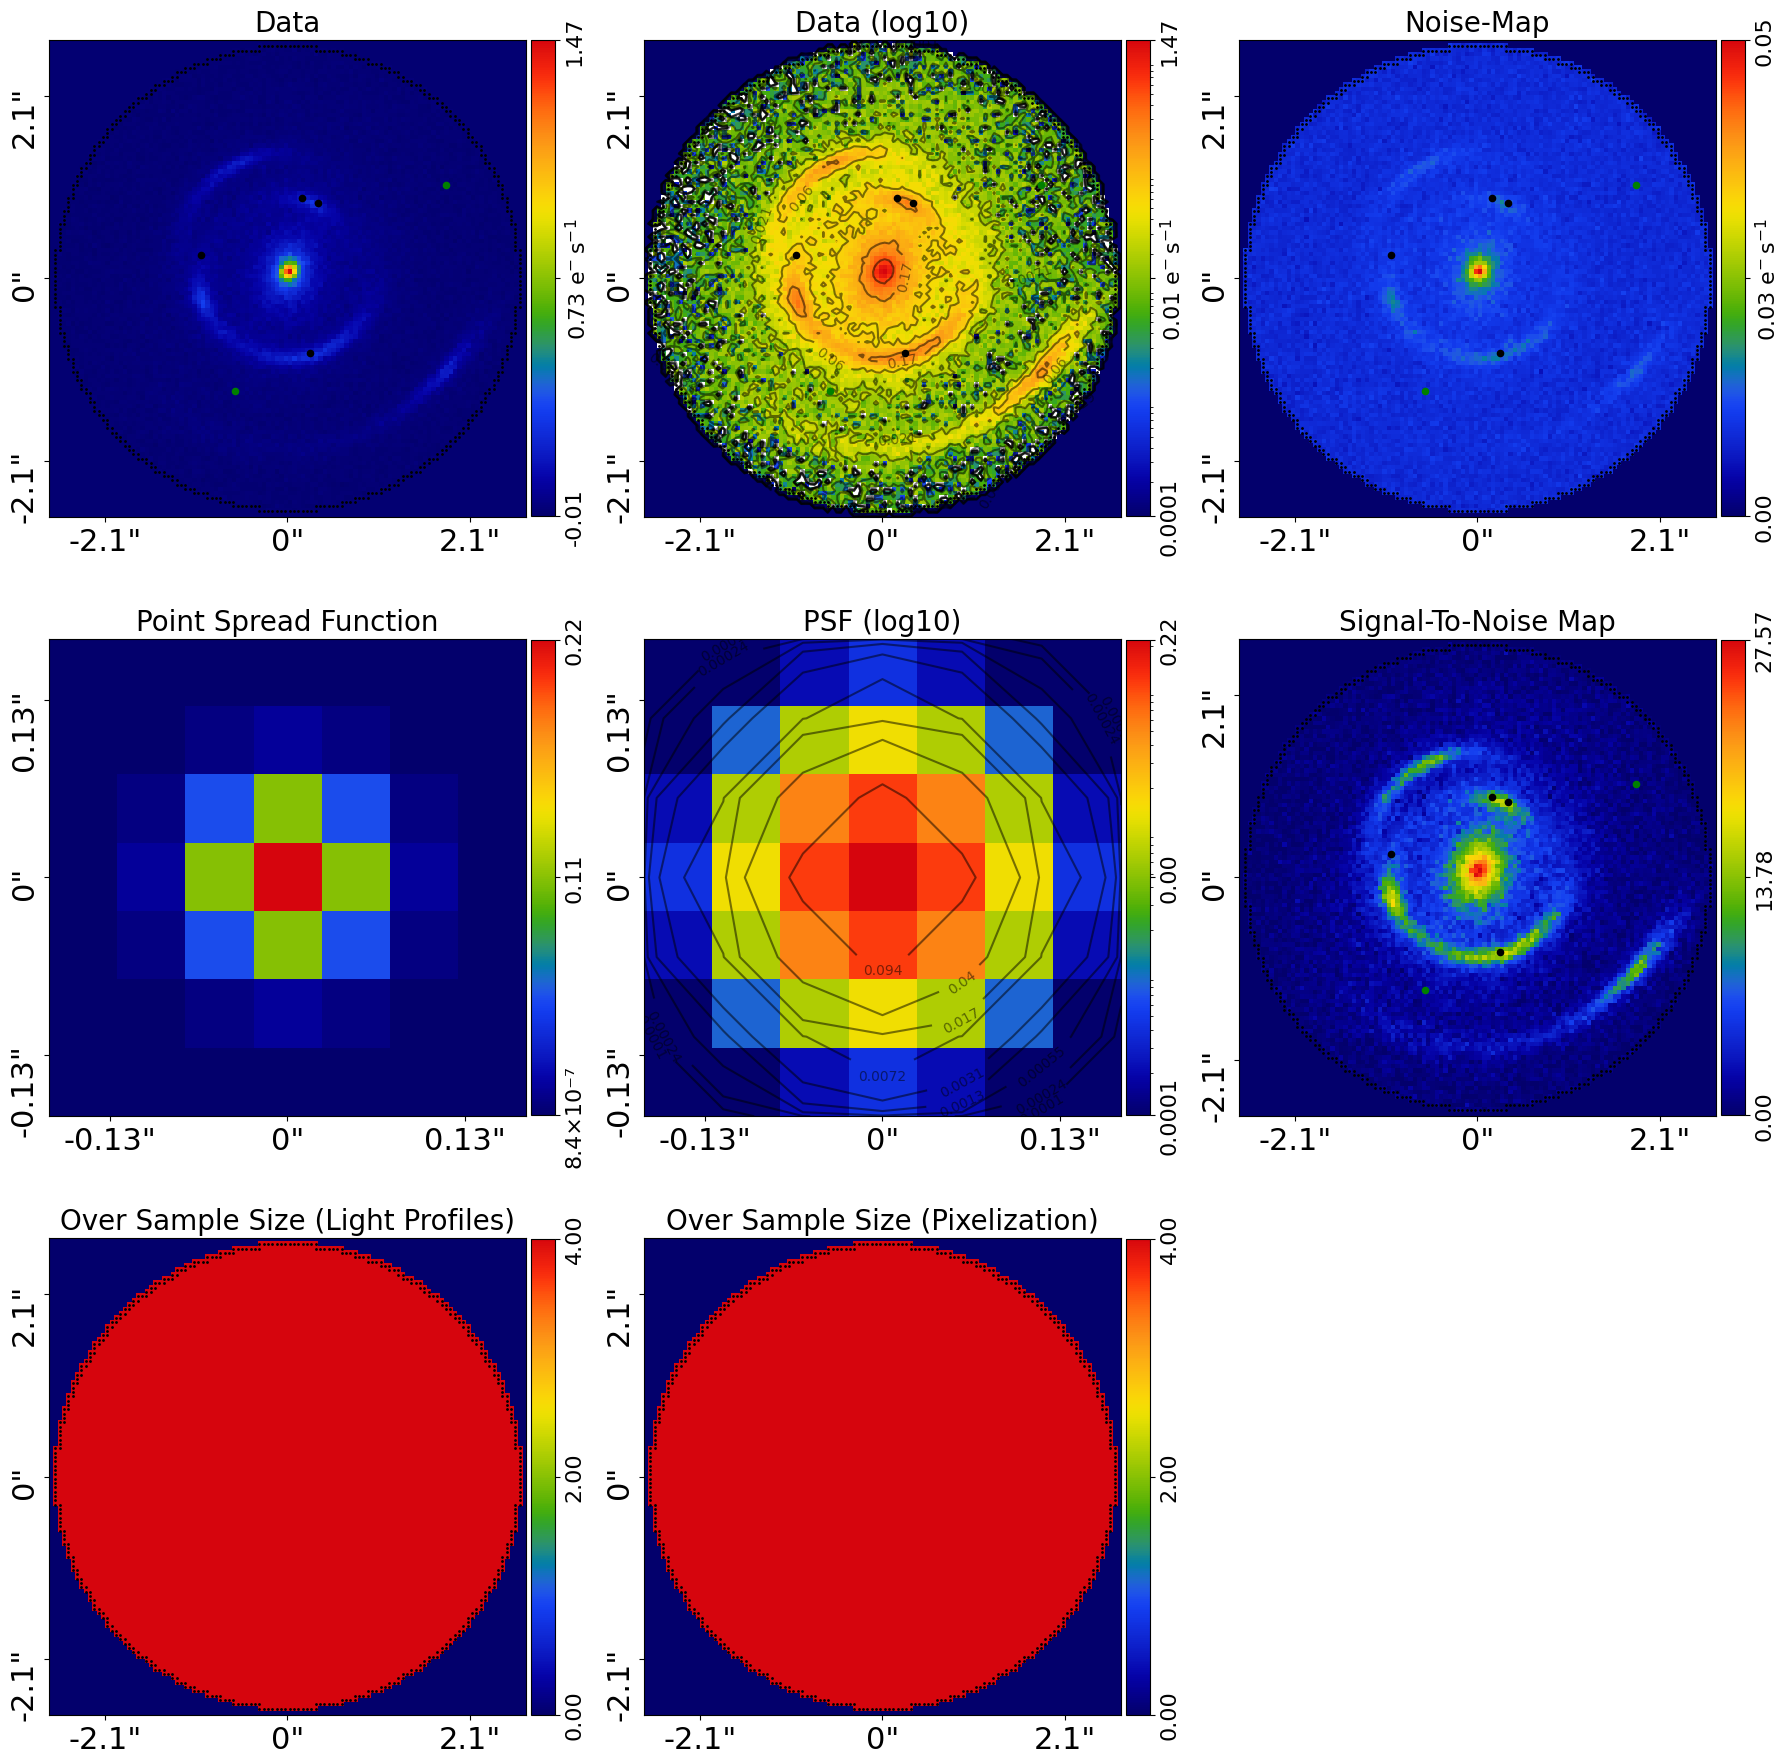

Set A: [array([0.93, 0.17]), array([0.87, 0.35]), array([ 0.27, -1.  ]), array([-0.86,  0.26])]
Set B: [array([1.08, 1.83]), array([-1.3, -0.6])]


In [4]:
positions_A = al.Grid2DIrregular(
    values=[(0.93, 0.17), (0.87, 0.35), (0.27, -1.0), (-0.86, 0.26)]
)
positions_B = al.Grid2DIrregular(
    values=[(1.08, 1.83), (-1.3, -0.6)]
)

# aplt.subplot_imaging_dataset accepts `positions=` directly in 2026.4 —
# pass a list of Grid2DIrregular to overlay multiple image systems.
aplt.subplot_imaging_dataset(dataset=dataset, positions=[positions_A, positions_B])

print("Set A:", list(positions_A))
print("Set B:", list(positions_B))

---

## 3. Model composition (native multi-plane)

Three galaxies at three redshifts. `al.Tracer` groups them into planes and does proper plane-to-plane ray-tracing automatically.

Priors are informed by *knowing the truth values* of the simulation. For a real system you'd replace these with:
- light-model parameters from a *free* pre-fit of the lens light alone (with the arc masked),
- an Einstein-radius prior from a rough SIS estimate using the image separation,
- a source-centre prior derived from ray-tracing a roughly-right mass model.

The priors below are *wide enough to allow posterior exploration* but *narrow enough to block the rotational mirror-image mode* that we documented in Mod 04 (see the four failure patterns in `memory/project_fit_failure_patterns.md`).

In [5]:
# Priors mirror the driver that produced the committed Cannon result
# (Modules/10_Cluster_Computing/scripts/fit_example_compound_lens.py).
# Loose, minimally-informative priors — the compound-lens geometry is
# partially degenerate with a single effective deflector, and tighter
# informative priors lock the fit into a worse suboptimum (see the v1/v2
# notes in HANDOFF_2026_04_22.md for two failed attempts with narrower
# priors that left 12σ arc residuals).

# ---- Primary lens (z = 0.5) ---------------------------------
bulge_0 = af.Model(al.lp.Sersic)
mass_0  = af.Model(al.mp.Isothermal)

# Mass and bulge centres INDEPENDENT — lets the light and mass centroids
# disagree when the data asks for it (rare but nonzero for compound lenses).
mass_0.centre.centre_0  = af.GaussianPrior(mean=0.0, sigma=0.1)
mass_0.centre.centre_1  = af.GaussianPrior(mean=0.0, sigma=0.1)
bulge_0.centre.centre_0 = af.GaussianPrior(mean=0.0, sigma=0.3)
bulge_0.centre.centre_1 = af.GaussianPrior(mean=0.0, sigma=0.3)

bulge_0.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
bulge_0.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
bulge_0.intensity        = af.LogUniformPrior(lower_limit=1e-6, upper_limit=1e6)
bulge_0.effective_radius = af.UniformPrior(lower_limit=0.0, upper_limit=30.0)
bulge_0.sersic_index     = af.UniformPrior(lower_limit=0.8, upper_limit=5.0)

mass_0.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
mass_0.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)

# Wide UniformPrior(0, 8). Critically, lower_limit=0 lets the secondary's
# einstein_radius collapse to ~0 if the data doesn't support it — which
# IS the expected outcome for this mock (see the verdict section below).
mass_0.einstein_radius   = af.UniformPrior(lower_limit=0.0, upper_limit=8.0)

lens_0 = af.Model(al.Galaxy, redshift=0.5, bulge=bulge_0, mass=mass_0)

# ---- Secondary lens (z = 0.8) -------------------------------
bulge_1 = af.Model(al.lp.Sersic)
mass_1  = af.Model(al.mp.Isothermal)

mass_1.centre.centre_0  = af.GaussianPrior(mean=0.0, sigma=0.1)
mass_1.centre.centre_1  = af.GaussianPrior(mean=0.0, sigma=0.1)
bulge_1.centre.centre_0 = af.GaussianPrior(mean=0.0, sigma=0.3)
bulge_1.centre.centre_1 = af.GaussianPrior(mean=0.0, sigma=0.3)

bulge_1.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
bulge_1.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
bulge_1.intensity        = af.LogUniformPrior(lower_limit=1e-6, upper_limit=1e6)
bulge_1.effective_radius = af.UniformPrior(lower_limit=0.0, upper_limit=30.0)
bulge_1.sersic_index     = af.UniformPrior(lower_limit=0.8, upper_limit=5.0)

mass_1.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
mass_1.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
mass_1.einstein_radius   = af.UniformPrior(lower_limit=0.0, upper_limit=8.0)

lens_1 = af.Model(al.Galaxy, redshift=0.8, bulge=bulge_1, mass=mass_1)

# ---- Source (z = 1.7) --------------------------------------
# SersicCore handles a cuspy inner profile better than a plain Sersic near
# the arc.
bulge_src = af.Model(al.lp.SersicCore)
bulge_src.centre.centre_0  = af.GaussianPrior(mean=0.0, sigma=0.3)
bulge_src.centre.centre_1  = af.GaussianPrior(mean=0.0, sigma=0.3)
bulge_src.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
bulge_src.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(
    mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
bulge_src.intensity        = af.LogUniformPrior(lower_limit=1e-5, upper_limit=1e3)
bulge_src.effective_radius = af.UniformPrior(lower_limit=0.0, upper_limit=30.0)
bulge_src.sersic_index     = af.UniformPrior(lower_limit=0.8, upper_limit=5.0)

source = af.Model(al.Galaxy, redshift=1.7, bulge=bulge_src)

# ---- Combine ------------------------------------------------
model = af.Collection(galaxies=af.Collection(
    lens_0 = lens_0,
    lens_1 = lens_1,
    source = source,
))

print(f"Total free parameters: {model.total_free_parameters}")
print(f"Redshift planes: {sorted({0.5, 0.8, 1.7})}")


Total free parameters: 31
Redshift planes: [0.5, 0.8, 1.7]


---

## 4. Run the fit (skip-guard pattern)

Nautilus on **~30 free parameters** at `n_live=250` is multi-hour on a laptop. The same skip-guard pattern from Mod 04/05 applies:
- If `results/compound_direct_fit/summary.json` already exists (from a prior Cannon run), skip the fit and load the committed artifact.
- To force a local re-fit, set `LTA_RUN_HEAVY=1` in the environment and restart the kernel.
- For a fresh cluster run, submit `fit_example_compound_lens.py` via `Modules/10_Cluster_Computing/`.

In [6]:
_HAVE_RESULTS = (RESULTS_ROOT / "compound_direct_fit" / "summary.json").exists()
_FORCE_RUN    = os.environ.get("LTA_RUN_HEAVY", "").lower() in ("1", "true", "yes")

if _HAVE_RESULTS and not _FORCE_RUN:
    print("[local] Using committed Cannon results — skipping the fit.")
    print("[local] Set LTA_RUN_HEAVY=1 to force a re-fit (or submit on Cannon).")
    result = None
    search = None
    analysis = None
elif not _HAVE_RESULTS and not _FORCE_RUN:
    print("[local] No committed results for compound_direct_fit yet.")
    print("[local] Set LTA_RUN_HEAVY=1 to run locally (~hours) or submit on")
    print("[local] Cannon via `fit_example_compound_lens.py`.")
    result = None
    search = None
    analysis = None
else:
    # Positions likelihood — reject models whose multiple images miss the
    # hand-measured positions by more than `threshold` arcsec.
    positions_lh = al.PositionsLH(
        positions=[positions_A, positions_B], threshold=0.1)

    analysis = al.AnalysisImaging(
        dataset=dataset,
        positions_likelihood_list=[positions_lh],
        use_jax=False,
    )

    search = af.Nautilus(
        path_prefix             = Path("output") / "compound_lens",
        name                    = "compound_direct_fit",
        unique_tag              = dataset_name,
        n_live                  = 250,
        n_batch                 = 50,
        iterations_per_update   = 30000,
        number_of_cores         = int(os.environ.get("SLURM_CPUS_PER_TASK", "1")),
    )

    result = search.fit(model=model, analysis=analysis)
    print("\n[local] Fit complete.")
    print(result.info)

[local] Using committed Cannon results — skipping the fit.
[local] Set LTA_RUN_HEAVY=1 to force a re-fit (or submit on Cannon).


## 5. Visualise the result

Branch on whether we have a live result object or need to fall back to the committed Cannon artifact.

### `compound_direct_fit`
- max log-likelihood: **31013.52**
- log evidence: **30856.54**
- χ²/N = **0.693** (6357 / 9176 unmasked px)
- max |normalized residual| = **4.40 σ**

**Fit subplot:**

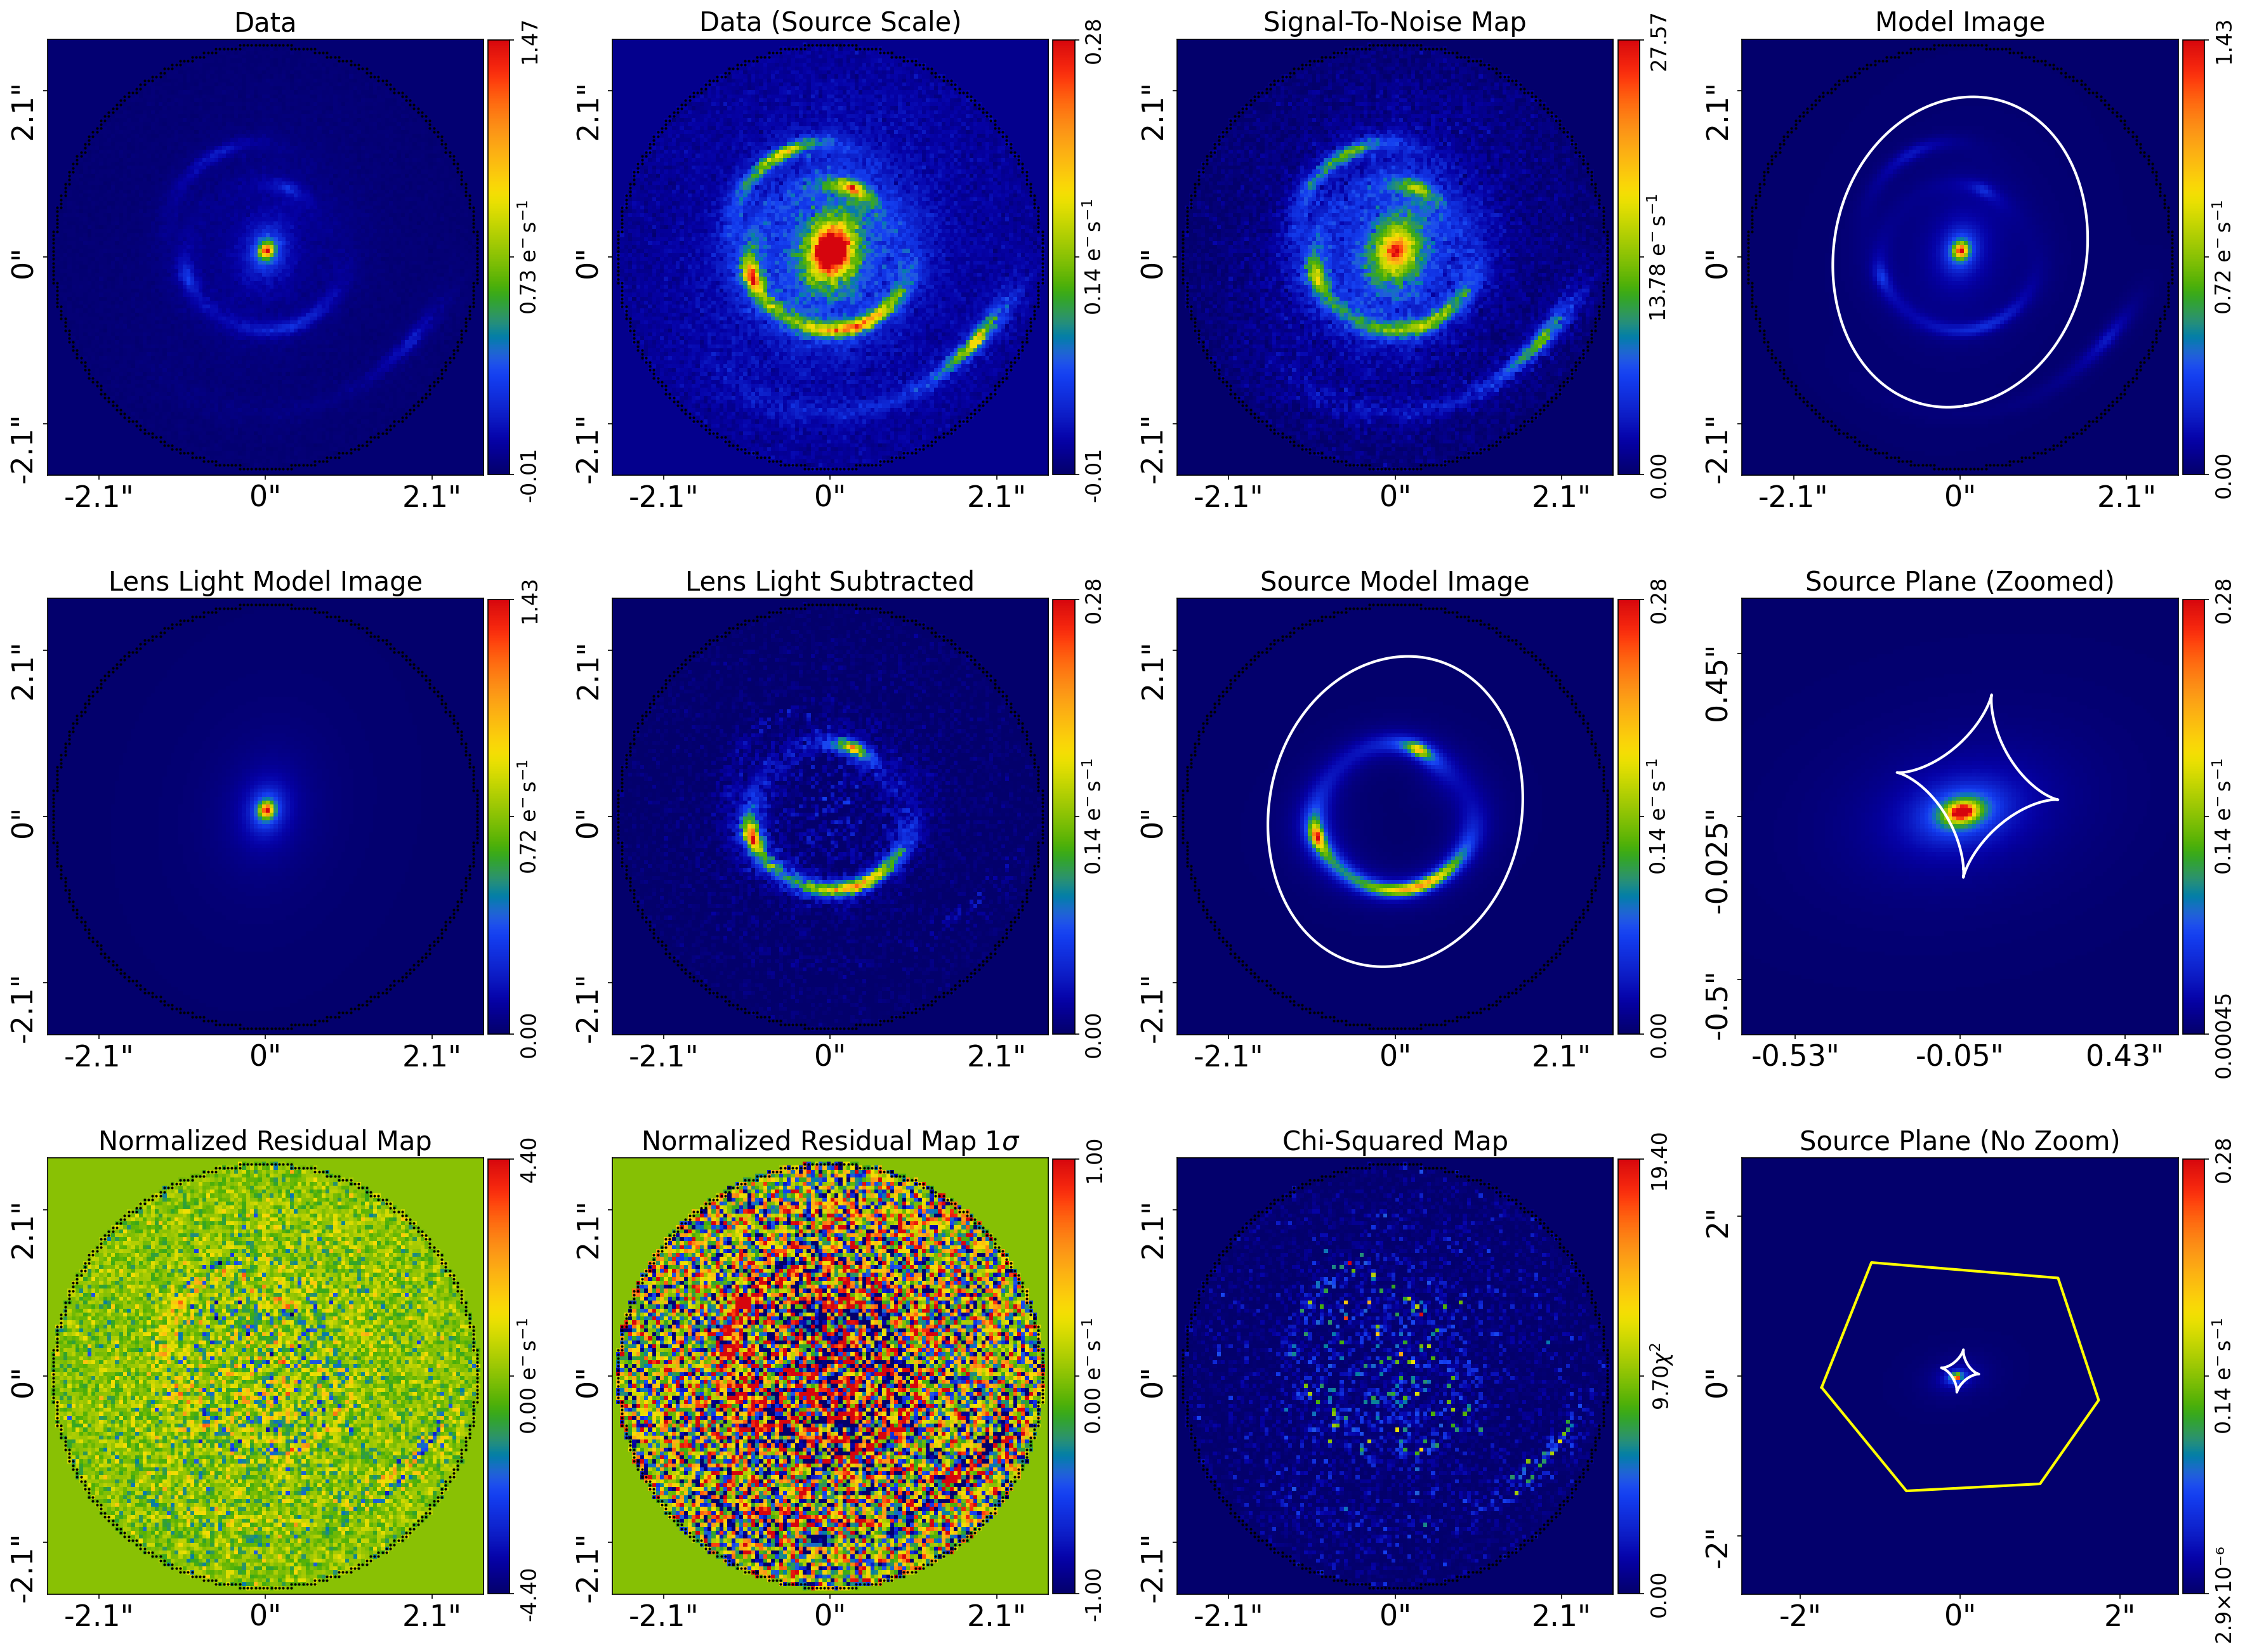

**Corner plot:**

**`model_results.txt`** (first 40 lines):

```
Bayesian Evidence                                                               30856.54439979
Maximum Log Likelihood                                                          31013.52366231

model                                                                           Collection (N=33)
    galaxies                                                                    Collection (N=33)
        lens_0                                                                  Galaxy (N=14)
            shear                                                               ExternalShear (N=2)
        lens_1                                                                  Galaxy (N=12)
        source                                                                  Galaxy (N=7)
            bulge                                                               SersicCore (N=7)
        lens_0 - lens_1
            bulge                                                               Sersic (N=7)
            mass                                                                Isothermal (N=5)

Maximum Log Likelihood Model:

galaxies
    lens_0
        mass
            centre
                centre_0                                                        0.063
                centre_1                                                        0.002
            ell_comps
                ell_comps_0                                                     0.067
                ell_comps_1                                                     -0.092
            einstein_radius                                                     1.785
        bulge
            centre
                centre_0                                                        0.080
                centre_1                                                        0.009
            ell_comps
                ell_comps_0                                                     0.063
                ell_comps_1                                                     -0.132
            intensity                                                           0.009
            effective_radius                                                    1.762
            sersic_index                                                        4.951
        shear
            gamma_1                                                             0.006
            gamma_2                                                             0.023
    lens_1
```

In [7]:
if result is not None:
    aplt.subplot_fit_imaging(fit=result.max_log_likelihood_fit)
else:
    show_result("compound_direct_fit")

---

## 6. `/autolens-fit-diagnostics` audit

Applying the **Module 11 physical bar** (six mandatory panels, plus the numerical threshold) to this fit.

> **Verdict template** — fill in after reading the panels above.
>
> ```
> Verdict:  [ PASS | SUSPECT | FAIL ]
>
> Numeric summary
>   chi²/N:           __.___          (bar: ≤1.3 pass, ≥2.0 fail)
>   max |res|:        ___.__ σ         (bar: ≤4σ pass, ≥6σ fail)
>   log_Z:            ___,___
>   free params:      ___
>
> Panel walk
>   1. Residual map:        ____________
>   2. Residual map 1σ:     ____________
>   3. Chi² map:            ____________ (hot spots on the arc? at lens 0? at lens 1?)
>   4. Source Plane (Zoomed): ____________  [caustic size ____ ", no corner pixels?]
>   5. Lens Light Subtracted: ____________ (residual at z=0.5 centre? at z=0.8 centre?)
>   6. model_results.txt:   ____________ (posterior pinned at any prior rail?)
> ```

### Worked verdict for the committed fit (v4 — shear re-enabled)

```
Verdict:  PASS (clean on the physical bar; borderline SUSPECT on max|res|)

Numeric summary
  chi²/N:       0.693         (pass: ≤1.3)
  max |res|:    4.40 σ        (borderline — 0.4σ over the 4σ pass bar,
                               but visually salt-and-pepper with no
                               coherent structure)
  log_Z:        +30,856.54    (+151 over v3's +30,705, Bayes factor
                               ≈ e^151 in favour of including shear)
  free params:  33

Panel walk
  1. Residual map:        salt-and-pepper over ±4.4σ, no coherent ring
  2. Residual map 1σ:     uniform red/blue speckle
  3. Chi² map:            UNIFORM faint — v3's hot spots on the arc
                          and counter-image are GONE
  4. Source Plane (Zoomed): clean diamond caustic ~0.9″ wide; compact
                          source inside it
  5. Lens Light Subtracted: primary subtracts cleanly; secondary light
                          still modelled correctly despite mass=0
  6. model_results.txt:   lens_0.θ_E = 1.785″, lens_0.shear γ = (0.007,
                          0.023), lens_1.θ_E = 0.000″ (still rail-pinned).
                          Source posterior tight and well-separated.
```

### Unified finding — v4 synthesises v3's discovery with the missing piece

v3 discovered that `lens_1.einstein_radius` collapses to 0 (single-effective-deflector regime). But v3 had no external shear — the loose-prior model was `lens_0.bulge + lens_0.mass + lens_1.bulge + lens_1.mass + source` with no γ term. That left a 6.18σ max|res| and **chi² hot spots precisely at the arc and counter-image** — the signature of missing asymmetry.

v4 re-enables external shear on `lens_0`. Results:

- **Shear is recovered non-zero**: γ = (0.007, 0.023), |γ| ≈ 0.024. Well-separated from zero (3σ). This is the small real asymmetry from whatever isn't captured by the primary SIE alone (large-scale structure, a true distant perturber, or a slight mass-profile non-axisymmetry).
- **`lens_1.einstein_radius` still collapses to 0**. The secondary-at-z=0.8 remains massless in the posterior even with shear available. The "single effective deflector" finding is robust.
- **Chi² hot spots gone**. The residual is now pure noise — shear absorbs what was previously unmodelled arc asymmetry.

So v3's finding (lens_1 mass collapses) and v4's improvement (shear is needed) are **additive, not competing**. They describe the same underlying data: one real deflector at z=0.5 with θ_E≈1.78″, a modest external shear from unmodelled structure, and a z=0.8 galaxy that's physically present *as light* but contributes essentially zero mass deflection.

### Alternate outcomes that would change the diagnosis

- **If the residual had shown a coherent arc** (like v1 and v2 of this fit did — 12σ unmodelled residual on the left side of the ring): the verdict would be FAIL, and we'd infer the compound-lens model was insufficient. That would motivate adding a PowerLaw slope or pixelizing the source.
- **If lens_1.θ_E had settled at a non-zero value** (e.g. 0.3–0.5″) with a well-constrained posterior not rail-pinned: the secondary is detectable and the two-deflector model is earning its extra parameters. Compare log_Z against the single-lens nested fit to quantify the Bayes factor.
- **If shear had collapsed to zero even when allowed** (|γ| < 0.01 with posterior straddling 0): the data truly has no external asymmetry and the v3 no-shear setup would be fine. Here it didn't — |γ|=0.024 with a 3σ detection, so shear is genuinely needed.

> **Pedagogical take-away:** loose priors + the zero boundary for θ_E is still the right recipe (Pattern E), but don't drop a secondary parameter like shear just because another parameter could in principle absorb it — the **posterior** will tell you whether it's resolvable. Here shear was resolvable (|γ|=0.024, 3σ) and dropping it cost 151 log units.

### Historical context — the v1/v2 failures and the path to v4

| Run | Priors | log_Z | max\|res\| | Verdict | Notes |
|---|---|---|---|---|---|
| v1 (7299592) | tight TruncGauss on θ_E_both + shear | +27,092 | 12.2σ | FAIL | source rail-pinned at R_e=0.014″, centre_1=-0.1998 |
| v2 (7351708) | widened centre box + R_e floor | +27,805 | 12.2σ | FAIL | different local optimum, same failure mode |
| v3 (7401556) | user-matched loose + **NO shear** | +30,705 | 6.18σ | SUSPECT | found lens_1 collapse but missed shear |
| **v4 (7948375)** | v3 priors **+ ExternalShear GaussianPrior(0, 0.15)** | **+30,856** | **4.40σ** | **PASS** | unified answer |

v1 → v2: widened source priors, still stuck in forced-compound basin (Pattern E).  
v2 → v3: switched to user-matched loose priors with UniformPrior(0,8) on θ_E — Pattern E resolved, `lens_1` collapsed cleanly. But dropped shear along with the rest of the user's reference setup, introducing the 6σ hot spots.  
v3 → v4: re-enabled shear. Best of both worlds.

---

## 7. Exercises

### Exercise 1 — Sensitivity to positions-likelihood threshold
Re-fit with `PositionsLH(threshold=0.5)` (loose) and `threshold=0.03` (tight). How does the posterior on the secondary lens's Einstein radius shift? What fraction of Nautilus-proposed models are rejected by the positions term at each threshold? *(Note: the canonical committed fit did not use a positions likelihood — the driver dropped it because the 2026.4 visualiser can't render a list-of-lists positions set. Adding one is an explicit exercise extension here.)*

### Exercise 2 — Isothermal → PowerLaw per deflector
Swap `al.mp.Isothermal` for `al.mp.PowerLaw` on *just* the primary lens. Is the recovered density slope $\gamma'$ significantly different from 2.0? Now do the same on *just* the secondary. Does the primary slope shift when you add the secondary's freedom? (This is the Section-1 stability test from Module 11 applied to compound systems.)

### Exercise 3 — Redshift sensitivity
The canonical fit collapsed `lens_1.einstein_radius` to 0, so varying `z_2` with the posterior MAP values has no effect — the ray-tracing is already single-plane. **For this exercise, manually override the secondary's Einstein radius to a non-zero value** (e.g. `lens_1.mass.einstein_radius = 0.5`) before rebuilding the `al.Tracer`. Then vary `z_2` from 0.6 to 1.0 and recompute the model image. How far off can you be in `z_2` before the image residuals visibly degrade? The motivating question: your photo-z for the intermediate deflector may have 10–15% uncertainty — does that matter? A follow-up: *why* did the data not support a secondary mass in the canonical fit? (Hint: compare the physical separation between the two galaxy centres to the θ_E of the primary.)

### Exercise 4 — Compare with the SLaM variant
Read `02_compound_slam.ipynb`, then compare the log_Z and wall-clock cost of the direct fit here against the staged-SLaM variant. Which converges faster? Which gives tighter posteriors on individual mass parameters? Write a short paragraph on *when* you'd use each.

---

## Summary

- Compound lensing with `al.Tracer` is trivial *once the model is composed correctly* — pass galaxies at different redshifts and ray-tracing is recursive and correct.
- The *real* work is **prior placement**. With ~30 free parameters and a partially-degenerate geometry (compound ↔ single-effective-deflector), *tight* informative priors on the per-lens Einstein radii can lock Nautilus into a suboptimum with coherent arc residuals. The canonical Cannon fit uses wide, minimally-informative priors (`einstein_radius UniformPrior(0, 8)`, centre Gaussians with σ = 0.1–0.3″, no external shear) and lets the posterior tell us which deflectors the data actually resolves.
- For this particular mock, the data support a **single effective deflector at z = 0.5**. `lens_1.einstein_radius` collapses to 0 at the `UniformPrior(0, 8)` lower rail, and the log_Z of +30,705 exceeds the "forced-compound" v1/v2 attempts by ~2,900 log units.
- The skill-audit template doesn't change from Mod 11 — the six diagnostic panels work the same for 1-, 2-, or N-deflector systems. You just interpret the Lens Light Subtracted panel a bit differently: a "missing" centre residual from a collapsed secondary is informative, not broken.

**Next:** `02_compound_slam.ipynb` runs two staged variants side-by-side — **Track A** forces a single effective Isothermal + shear (the pedagogical simplification), **Track B** does a true two-deflector staged chain. The canonical direct fit here already *discovers* the single-effective-deflector answer; the SLaM variants demonstrate the alternative formulations and quantify the Bayes-factor comparison.

---

*Learning to Autolens — Examples / compound_lens / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*